# EDA



eda motivations:

- cardinality and target distribution;
- data quality
- cardinality of categorical variables;
- dataset structure and missing values;
- population representation

guidlines:
- Only 200 samples (possibly not all od them are valid)
- Multiple fields related to the work place and role title
- Some fields may be open-ended, meaning respondents can fill them in using their own words. 
- understand if SemelMishlachSofi is denser than target variable. predicting industry context first may narrow the occupation search space, and a potentially less sparse intermediate target may provide a more stable signal for the final prediction.



In [1]:
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_colwidth", 100)


DATA_PATH = "DUMMY_DATASET.xlsx"
SHEET_NAME = "Survey Dataset"
EMBEDDINGS_PATH = "survey_with_embeddings.pkl"
EMBEDDING_COL = "embedding"
ID_COL = "ID"
TARGET_COL = "SemelMishlachSofi"
INDUSTRY_COL = "SemelAnafSofi"
TEXT_COLS = [
    "ShemAvoda",
    "SugAvoda",
    "ShemMachlaka",
    "SugMachlaka",
    "EzoAvoda",
    "TeurPeula",
    "TeurTafkid",
]
TEXT_ORDER_FOR_BASELINE = [
    "EzoAvoda",
    "SugAvoda",
    "ShemAvoda",
    "ShemMachlaka",
    "SugMachlaka",
    "TeurPeula",
    "TeurTafkid",
]
BOW_MAX_FEATURES = 6000
TFIDF_MAX_FEATURES = 6000

from eda_utils import (
    # load_survey_data,
    normalize_code,
    add_target_levels,
    missing_values_summary,
    support_distribution,
    categorical_overview,
    add_text_features,
    bow_document_frequency,
    vectorize_text,
    load_embeddings_if_available,
    stack_embedding_column,
    compute_silhouette_for_labels,
    centroid_similarity_diagnostics,
    summarize_centroid_margin,
    pca_projection,
)

print("Data path:", Path(DATA_PATH).resolve())
print("Embeddings path:", Path(EMBEDDINGS_PATH).resolve())


Data path: /Users/yanadrevin/home_assignments/Central_Bureau_of_Statistics/cbs_data_analysis_bundle_v3_clean/DUMMY_DATASET.xlsx
Embeddings path: /Users/yanadrevin/home_assignments/Central_Bureau_of_Statistics/cbs_data_analysis_bundle_v3_clean/survey_with_embeddings.pkl


## 1. Load data and compact overview

In [3]:
raw_df = pd.read_excel(DATA_PATH).iloc[:200] # last row is invalid 


In [4]:
df = add_target_levels(raw_df, target_col=TARGET_COL)
df = add_text_features(df, text_cols=TEXT_ORDER_FOR_BASELINE)
df["TeudaGvoha"] = df.apply(lambda x: normalize_code(x["TeudaGvoha"]), axis=1)
df["MaamadAvoda"] = df.apply(lambda x: normalize_code(x["MaamadAvoda"]), axis=1)


display(df)

display(df.info())

,ID,YeshuvAvoda,ShemAvoda,SugAvoda,ShemMachlaka,SugMachlaka,EzoAvoda,TeurPeula,TeurTafkid,MenahelEtMi,MaamadAvoda,MakorSachar,TeudaGvoha,shnotlimud,Gil,TarichHathala,SemelAnafSofi,SemelMishlachSofi,target_l1,target_l2,target_l3,target_l4,embedding_text,bow_tfidf_text,text_char_count,text_word_count,text_non_missing_field_count
0,1.0,ירושלים,"למ""ס","איסוף, עיבוד ופרסום נתונים",מיקרו כלכלה,טיפול בנתוני מיקרו,סגן מנהל אגף,"כנ""ל",סגן מנהל אגף,3.0,1,1.0,6,22.0,55.0,2020-06-15,8411,2120,2,21,212,2120,"תיאור מקום עבודה ותפקיד: סגן מנהל אגף ,איסוף, עיבוד ופרסום נתונים ,למ""ס ,מיקרו כלכלה ,טיפול בנתו...","סגן מנהל אגף | איסוף, עיבוד ופרסום נתונים | למ""ס | מיקרו כלכלה | טיפול בנתוני מיקרו",83,17,6
1,2.0,ירושלים,בית חולים הדסה עין כרם,טיפול בחולים,רדיואתרפיה,טיפול בחולי סרטן,טכנאית רדיותרפיה,"כנ""ל","כנ""ל",NaN,1,1.0,6,22.0,55.0,2022-07-01,8610,3311,3,33,331,3311,"תיאור מקום עבודה ותפקיד: טכנאית רדיותרפיה ,טיפול בחולים ,בית חולים הדסה עין כרם ,רדיואתרפיה ,טיפ...",טכנאית רדיותרפיה | טיפול בחולים | בית חולים הדסה עין כרם | רדיואתרפיה | טיפול בחולי סרטן,88,17,5
2,3.0,באר שבע,קריית הממשלה,מתן שירות למשתמשים באתר GOV,תמיכה בלקוחות,"כנ""ל",נותנת תמיכה ללקוחות שמבקשים עזרה,מסבירה איך להשתמש בשירותים ממשלתיים באתר האינטרנט,NaN,NaN,1,1.0,5,15.0,29.0,2021-06-06,8411,3512,3,35,351,3512,"תיאור מקום עבודה ותפקיד: נותנת תמיכה ללקוחות שמבקשים עזרה ,מתן שירות למשתמשים באתר GOV ,קריית המ...",נותנת תמיכה ללקוחות שמבקשים עזרה | מתן שירות למשתמשים באתר GOV | קריית הממשלה | תמיכה בלקוחות | ...,145,25,5
3,4.0,תל אביב,משרד החינוך,בית ספר יסודי,שמירה,NaN,שומר בבית הספר,NaN,NaN,NaN,1,2.0,3,12.0,48.0,2024-07-01,8010,5414,5,54,541,5414,"תיאור מקום עבודה ותפקיד: שומר בבית הספר ,בית ספר יסודי ,משרד החינוך ,שמירה",שומר בבית הספר | בית ספר יסודי | משרד החינוך | שמירה,52,12,4
4,5.0,תל אביב,אמיר כהן,מטפל בקשיש במשפחה,NaN,NaN,מטפל בקשיש,"נותן אוכל, עוזר בניקיון בית, עוזר להתרחץ",NaN,NaN,1,1.0,4,14.0,42.0,2010-01-11,XXXX,5322,5,53,532,5322,"תיאור מקום עבודה ותפקיד: מטפל בקשיש ,מטפל בקשיש במשפחה ,אמיר כהן ,נותן אוכל, עוזר בניקיון בית, ע...","מטפל בקשיש | מטפל בקשיש במשפחה | אמיר כהן | נותן אוכל, עוזר בניקיון בית, עוזר להתרחץ",84,17,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196.0,תל אביב,משטרה,חבלן,חבלן,NaN,חבלן,NaN,NaN,NaN,1,1.0,4,14.0,25.0,2020-05-31,8423,5412,5,54,541,5412,"תיאור מקום עבודה ותפקיד: חבלן ,משטרה",חבלן | משטרה,12,3,4
196,197.0,תל אביב,מסעדת נונה,מסעדה,NaN,NaN,מלצר,NaN,NaN,NaN,1,1.0,4,13.0,40.0,2000-07-15,5610,5131,5,51,513,5131,"תיאור מקום עבודה ותפקיד: מלצר ,מסעדה ,מסעדת נונה",מלצר | מסעדה | מסעדת נונה,25,6,3
197,198.0,בת ים,קוסמטיקאית,NaN,NaN,NaN,קוסמטיקאית,NaN,NaN,NaN,4,1.0,3,12.0,35.0,2024-07-31,9602,5142,5,51,514,5142,תיאור מקום עבודה ותפקיד: קוסמטיקאית,קוסמטיקאית,10,1,2
198,199.0,חדרה,גן חדרה,גננת,חינוך,גננת,גננת,NaN,NaN,NaN,1,1.0,4,15.0,38.0,2011-02-01,8501,2342,2,23,234,2342,"תיאור מקום עבודה ותפקיד: גננת ,גן חדרה ,חינוך",גננת | גן חדרה | חינוך,22,6,5


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ID                            200 non-null    float64       
 1   YeshuvAvoda                   200 non-null    str           
 2   ShemAvoda                     200 non-null    str           
 3   SugAvoda                      175 non-null    str           
 4   ShemMachlaka                  136 non-null    str           
 5   SugMachlaka                   66 non-null     str           
 6   EzoAvoda                      193 non-null    str           
 7   TeurPeula                     64 non-null     str           
 8   TeurTafkid                    28 non-null     object        
 9   MenahelEtMi                   32 non-null     float64       
 10  MaamadAvoda                   198 non-null    str           
 11  MakorSachar                   186 non-null 

None

In [5]:

overview = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "unique target codes",
            "unique concrete level-1 target groups",
            "unique concrete level-2 target groups",
            "unique concrete level-3 target groups",
            "unique concrete level-4 target groups",
            "unique industry codes",
        ],
        "value": [
            len(df),
            df.shape[1],
            df[TARGET_COL].dropna().astype(str).nunique(),
            df["target_l1"].dropna().astype(str).nunique(),
            df["target_l2"].dropna().astype(str).nunique(),
            df["target_l3"].dropna().astype(str).nunique(),
            df["target_l4"].dropna().astype(str).nunique(),
            df[INDUSTRY_COL].dropna().astype(str).nunique(),
        ],
    }
)
display(overview)

dtype_summary = (
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="number_of_columns")
)
display(dtype_summary)


,metric,value
0,rows,200
1,columns,27
2,unique target codes,62
3,unique concrete level-1 target groups,8
4,unique concrete level-2 target groups,29
5,unique concrete level-3 target groups,46
6,unique concrete level-4 target groups,59
7,unique industry codes,44


,dtype,number_of_columns
0,str,16
1,float64,5
2,int64,3
3,object,2
4,datetime64[us],1


### Numeric description

Only numeric columns are displayed here to keep the output compact. Categorical fields are summarized later by value counts and support buckets.

In [6]:

display(df.describe(exclude=["object"]).T)




,count,mean,min,25%,50%,75%,max,std
ID,200.0,100.5,1.0,50.75,100.5,150.25,200.0,57.879185
MenahelEtMi,32.0,2.15625,1.0,1.75,2.0,3.0,3.0,0.8076
MakorSachar,186.0,1.33871,1.0,1.0,1.0,1.0,4.0,0.711532
shnotlimud,198.0,14.313131,7.0,12.0,14.0,16.0,22.0,2.917291
Gil,198.0,39.454545,22.0,31.0,37.0,46.0,78.0,12.611149
TarichHathala,200,2017-07-10 14:38:24,1999-06-06 00:00:00,2011-11-08 12:00:00,2022-04-01 00:00:00,2022-11-11 00:00:00,2026-06-06 00:00:00,NaN
text_char_count,200.0,52.915,5.0,32.0,48.0,69.25,149.0,30.318042
text_word_count,200.0,10.99,1.0,7.0,10.0,14.25,30.0,5.782481
text_non_missing_field_count,200.0,4.19,1.0,3.0,4.0,5.0,7.0,1.327672


### Exploratory Inspection of Example Occupation Groups
This section displays all available columns for a small number of selected occupation-code groups, allowing us to compare the raw survey responses, and structured fields at the record level.

In [7]:
from IPython.display import display, HTML

def display_scrollable_df(
    df,
    title=None,
    max_height="300px",
    max_width="100%",
    index=False
):
    title_html = f"<h4 style='margin-bottom: 8px;'>{title}</h4>" if title else ""

    html = f"""
    {title_html}
    <div style="
        max-height: {max_height};
        max-width: {max_width};
        overflow: auto;
        border: 1px solid #ccc;
        padding: 8px;
    ">
        {df.to_html(index=index)}
    </div>
    """

    display(HTML(html))
    
display_scrollable_df(df[df[TARGET_COL] == "4313"], "category 4313")
display_scrollable_df(df[df[TARGET_COL] == "5131"], "category 5131")
display_scrollable_df(df[df[TARGET_COL] == "2342"], "category 2342")



ID,YeshuvAvoda,ShemAvoda,SugAvoda,ShemMachlaka,SugMachlaka,EzoAvoda,TeurPeula,TeurTafkid,MenahelEtMi,MaamadAvoda,MakorSachar,TeudaGvoha,shnotlimud,Gil,TarichHathala,SemelAnafSofi,SemelMishlachSofi,target_l1,target_l2,target_l3,target_l4,embedding_text,bow_tfidf_text,text_char_count,text_word_count,text_non_missing_field_count
21.0,שדרות,אוסם,ייצור פסטה,הנהלת חשבונות,חישובי שכר לעובדים,חשבת שכר לעובדים,NaN,NaN,NaN,1,1.0,4,14.0,37.0,2022-11-01,1074,4313,4,43,431,4313,"תיאור מקום עבודה ותפקיד: חשבת שכר לעובדים ,ייצור פסטה ,אוסם ,הנהלת חשבונות ,חישובי שכר לעובדים",חשבת שכר לעובדים | ייצור פסטה | אוסם | הנהלת חשבונות | חישובי שכר לעובדים,73,15,5
53.0,נוף הגליל,עלית,עוגות,הנהלת חשבונות,חשבת שכר לעובדים,חישובי שכר לעובדים,חישובי שכר לעובדים,NaN,NaN,1,1.0,4,14.0,37.0,2022-11-01,1073,4313,4,43,431,4313,"תיאור מקום עבודה ותפקיד: חישובי שכר לעובדים ,עוגות ,עלית ,הנהלת חשבונות ,חשבת שכר לעובדים",חישובי שכר לעובדים | עוגות | עלית | הנהלת חשבונות | חשבת שכר לעובדים,68,14,6
84.0,שדרות,אוסם,ייצור פסטה,הנהלת חשבונות,חישובי שכר לעובדים,חשבת שכר לעובדים,NaN,NaN,NaN,1,1.0,4,14.0,37.0,2022-11-01,1074,4313,4,43,431,4313,"תיאור מקום עבודה ותפקיד: חשבת שכר לעובדים ,ייצור פסטה ,אוסם ,הנהלת חשבונות ,חישובי שכר לעובדים",חשבת שכר לעובדים | ייצור פסטה | אוסם | הנהלת חשבונות | חישובי שכר לעובדים,73,15,5
116.0,נוף הגליל,עלית,עוגות,הנהלת חשבונות,חישובי שכר לעובדים,חשבת שכר לעובדים,NaN,NaN,NaN,1,1.0,4,14.0,37.0,2022-11-01,1073,4313,4,43,431,4313,"תיאור מקום עבודה ותפקיד: חשבת שכר לעובדים ,עוגות ,עלית ,הנהלת חשבונות ,חישובי שכר לעובדים",חשבת שכר לעובדים | עוגות | עלית | הנהלת חשבונות | חישובי שכר לעובדים,68,14,5


ID,YeshuvAvoda,ShemAvoda,SugAvoda,ShemMachlaka,SugMachlaka,EzoAvoda,TeurPeula,TeurTafkid,MenahelEtMi,MaamadAvoda,MakorSachar,TeudaGvoha,shnotlimud,Gil,TarichHathala,SemelAnafSofi,SemelMishlachSofi,target_l1,target_l2,target_l3,target_l4,embedding_text,bow_tfidf_text,text_char_count,text_word_count,text_non_missing_field_count
13.0,ירושלים,מסעדה,מסעדה,NaN,NaN,מלצר,NaN,NaN,NaN,1,1.0,3,14.0,23.0,2022-08-01,5610,5131,5,51,513,5131,"תיאור מקום עבודה ותפקיד: מלצר ,מסעדה",מלצר | מסעדה,12,3,3
76.0,אילת,מסעדה,מסעדה,NaN,NaN,מלצר,NaN,NaN,NaN,1,1.0,3,14.0,23.0,2022-08-01,5610,5131,5,51,513,5131,"תיאור מקום עבודה ותפקיד: מלצר ,מסעדה",מלצר | מסעדה,12,3,3
192.0,חיפה,מסעדת טעמים,מסעדה,NaN,NaN,מלצר,NaN,NaN,NaN,1,1.0,4,13.0,40.0,2000-07-15,5610,5131,5,51,513,5131,"תיאור מקום עבודה ותפקיד: מלצר ,מסעדה ,מסעדת טעמים",מלצר | מסעדה | מסעדת טעמים,26,6,3
195.0,אילת,ישרוטל,מלצר,מסעדה,NaN,מלצר,NaN,NaN,NaN,1,1.0,1,12.0,32.0,2022-04-11,5510,5131,5,51,513,5131,"תיאור מקום עבודה ותפקיד: מלצר ,ישרוטל ,מסעדה",מלצר | ישרוטל | מסעדה,21,5,4
197.0,תל אביב,מסעדת נונה,מסעדה,NaN,NaN,מלצר,NaN,NaN,NaN,1,1.0,4,13.0,40.0,2000-07-15,5610,5131,5,51,513,5131,"תיאור מקום עבודה ותפקיד: מלצר ,מסעדה ,מסעדת נונה",מלצר | מסעדה | מסעדת נונה,25,6,3


ID,YeshuvAvoda,ShemAvoda,SugAvoda,ShemMachlaka,SugMachlaka,EzoAvoda,TeurPeula,TeurTafkid,MenahelEtMi,MaamadAvoda,MakorSachar,TeudaGvoha,shnotlimud,Gil,TarichHathala,SemelAnafSofi,SemelMishlachSofi,target_l1,target_l2,target_l3,target_l4,embedding_text,bow_tfidf_text,text_char_count,text_word_count,text_non_missing_field_count
19.0,ירושלים,עיריית ירושלים,גן ילדים,NaN,NaN,גננת לגילאים 4-6,NaN,NaN,NaN,1,4.0,5,15.0,38.0,2011-02-01,8501,2342,2,23,234,2342,"תיאור מקום עבודה ותפקיד: גננת לגילאים 4-6 ,גן ילדים ,עיריית ירושלים",גננת לגילאים 4-6 | גן ילדים | עיריית ירושלים,44,9,3
51.0,ירושלים,עיריית ירושלים,גן ילדים,חינוך,NaN,גננת,NaN,NaN,NaN,1,4.0,5,15.0,38.0,2011-02-01,8501,2342,2,23,234,2342,"תיאור מקום עבודה ותפקיד: גננת ,גן ילדים ,עיריית ירושלים ,חינוך",גננת | גן ילדים | עיריית ירושלים | חינוך,40,9,4
82.0,אילת,עיריית תל אילת,גן ילדים,NaN,NaN,גננת לגילאים 4-6,NaN,NaN,NaN,1,4.0,5,15.0,38.0,2011-02-01,8501,2342,2,23,234,2342,"תיאור מקום עבודה ותפקיד: גננת לגילאים 4-6 ,גן ילדים ,עיריית תל אילת",גננת לגילאים 4-6 | גן ילדים | עיריית תל אילת,44,10,3
114.0,חדרה,עיריית חדרה,גן ילדים,חינוך,NaN,גננת,NaN,NaN,NaN,1,4.0,5,15.0,38.0,2011-02-01,8501,2342,2,23,234,2342,"תיאור מקום עבודה ותפקיד: גננת ,גן ילדים ,עיריית חדרה ,חינוך",גננת | גן ילדים | עיריית חדרה | חינוך,37,9,4
199.0,חדרה,גן חדרה,גננת,חינוך,גננת,גננת,NaN,NaN,NaN,1,1.0,4,15.0,38.0,2011-02-01,8501,2342,2,23,234,2342,"תיאור מקום עבודה ותפקיד: גננת ,גן חדרה ,חינוך",גננת | גן חדרה | חינוך,22,6,5


## 2. Missing values


Columns with missing values: 16 out of 27


,column,missing_count,missing_fraction,non_missing_count,dtype
0,TeurTafkid,172,86.0%,28,object
1,MenahelEtMi,168,84.0%,32,float64
2,TeurPeula,136,68.0%,64,str
3,SugMachlaka,134,67.0%,66,str
4,ShemMachlaka,64,32.0%,136,str
5,SugAvoda,25,12.5%,175,str
6,MakorSachar,14,7.0%,186,float64
7,target_l4,9,4.5%,191,str
8,target_l2,8,4.0%,192,str
9,target_l3,8,4.0%,192,str


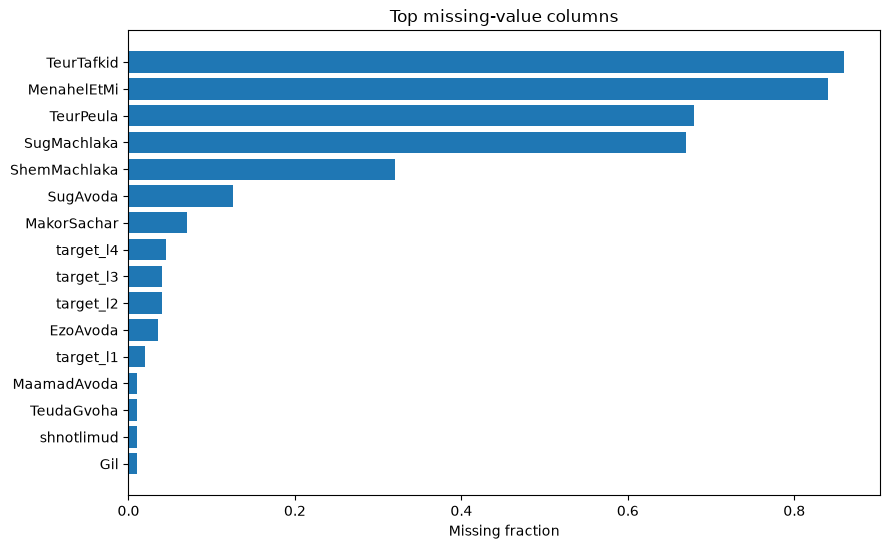

In [8]:
missing_summary = missing_values_summary(df)

missing_nonzero = (
    missing_summary
    .query("missing_count > 0")
    .reset_index()
    .rename(columns={"index": "column"})
    .sort_values("missing_fraction", ascending=False)
)

print(f"Columns with missing values: {len(missing_nonzero)} out of {df.shape[1]}")

display(
    missing_nonzero[
        ["column", "missing_count", "missing_fraction", "non_missing_count", "dtype"]
    ].head(20).style.format({"missing_fraction": "{:.1%}"})
)

plot_df = missing_nonzero.head(20).sort_values("missing_fraction", ascending=True)

fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(plot_df))))
ax.barh(plot_df["column"], plot_df["missing_fraction"])
ax.set_xlabel("Missing fraction")
ax.set_title("Top missing-value columns")
plt.tight_layout()
plt.show()


## 3. Data Quality

In [25]:

DUPLICATE_KEY_COLUMNS = [
    "ShemAvoda",
    "SugAvoda",
    "ShemMachlaka",
    "SugMachlaka",
    "EzoAvoda",
    "TeurPeula",
    "TeurTafkid",
    "MenahelEtMi",
    "MakorSachar",
    "MaamadAvoda",
    "TeudaGvoha",
    "shnotlimud",
    "Gil",
    "TarichHathala",
    "SemelAnafSofi'"
    
]

# Keep only columns that actually exist in the dataset
DUPLICATE_KEY_COLUMNS = [c for c in DUPLICATE_KEY_COLUMNS if c in df.columns]

analysis_df = df.copy()

# Normalize text/key fields so that small formatting differences do not hide duplicates
for col in DUPLICATE_KEY_COLUMNS:
    analysis_df[col] = (
        analysis_df[col]
        .astype("string")
        .fillna("<missing>")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )



# Count how many rows and how many distinct targets exist per duplicate-key group
duplicate_target_summary = (
    analysis_df
    .groupby(DUPLICATE_KEY_COLUMNS, dropna=False)
    .agg(
        n_records=(ID_COL, "count"),
        n_unique_targets=(TARGET_COL, "nunique"),
        target_values=(TARGET_COL, lambda x: sorted(x.dropna().unique())),
        ids=(ID_COL, lambda x: list(x)),
    )
    .reset_index()
)

# Groups where the same input appears more than once with different target values
conflicting_duplicates = duplicate_target_summary[
    (duplicate_target_summary["n_records"] > 1)
    & (duplicate_target_summary["n_unique_targets"] > 1)
].sort_values(["n_unique_targets", "n_records"], ascending=False)

print("Duplicate-like input groups with different target values:", len(conflicting_duplicates))

display(
    conflicting_duplicates[
        ["n_records", "n_unique_targets", "target_values", "ids"] + DUPLICATE_KEY_COLUMNS
    ].head(20)
)

# Optional: show the original rows for the conflicting groups
if len(conflicting_duplicates) > 0:
    conflicting_keys = conflicting_duplicates[DUPLICATE_KEY_COLUMNS].drop_duplicates()

    conflicting_rows = analysis_df.merge(
        conflicting_keys,
        on=DUPLICATE_KEY_COLUMNS,
        how="inner",
    ).sort_values(DUPLICATE_KEY_COLUMNS + [TARGET_COL])

    display_cols = [ID_COL, TARGET_COL] + DUPLICATE_KEY_COLUMNS

    display_cols = [c for c in display_cols if c in conflicting_rows.columns]

    display(conflicting_rows[display_cols].head(50))

Duplicate-like input groups with different target values: 1


,n_records,n_unique_targets,target_values,ids,ShemAvoda,SugAvoda,ShemMachlaka,SugMachlaka,EzoAvoda,TeurPeula,TeurTafkid,MenahelEtMi,MakorSachar,MaamadAvoda,TeudaGvoha,shnotlimud,Gil,TarichHathala
30,4,2,"[3211, 3311]","[2.0, 33.0, 65.0, 96.0]",בית חולים הדסה עין כרם,טיפול בחולים,רדיואתרפיה,טיפול בחולי סרטן,טכנאית רדיותרפיה,"כנ""ל","כנ""ל",<missing>,1.0,1,6,22.0,55.0,2022-07-01


,ID,SemelMishlachSofi,ShemAvoda,SugAvoda,ShemMachlaka,SugMachlaka,EzoAvoda,TeurPeula,TeurTafkid,MenahelEtMi,MakorSachar,MaamadAvoda,TeudaGvoha,shnotlimud,Gil,TarichHathala
1,33.0,3211,בית חולים הדסה עין כרם,טיפול בחולים,רדיואתרפיה,טיפול בחולי סרטן,טכנאית רדיותרפיה,"כנ""ל","כנ""ל",<missing>,1.0,1,6,22.0,55.0,2022-07-01
2,65.0,3211,בית חולים הדסה עין כרם,טיפול בחולים,רדיואתרפיה,טיפול בחולי סרטן,טכנאית רדיותרפיה,"כנ""ל","כנ""ל",<missing>,1.0,1,6,22.0,55.0,2022-07-01
3,96.0,3211,בית חולים הדסה עין כרם,טיפול בחולים,רדיואתרפיה,טיפול בחולי סרטן,טכנאית רדיותרפיה,"כנ""ל","כנ""ל",<missing>,1.0,1,6,22.0,55.0,2022-07-01
0,2.0,3311,בית חולים הדסה עין כרם,טיפול בחולים,רדיואתרפיה,טיפול בחולי סרטן,טכנאית רדיותרפיה,"כנ""ל","כנ""ל",<missing>,1.0,1,6,22.0,55.0,2022-07-01


## 4. Target-code sparsity: `SemelMishlachSofi`

The target contains many low-support exact codes. This motivates hierarchical prediction and manual routing for uncertain cases.

,metric,value
0,unique target codes,62
1,singleton target codes,25
2,target codes with 2 samples,9
3,target codes with <= 3 samples,38
4,largest target group size,14


,field,support_bucket,number_of_categories
0,SemelMishlachSofi,1,25
1,SemelMishlachSofi,2,9
2,SemelMishlachSofi,3,4
3,SemelMishlachSofi,4-5,13
4,SemelMishlachSofi,6-10,9
5,SemelMishlachSofi,>10,2


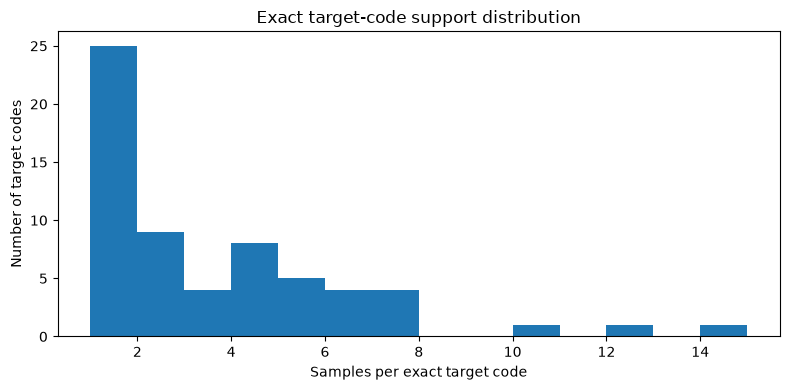

In [9]:
target_counts = df[TARGET_COL].dropna().astype(str).value_counts()

target_summary = pd.DataFrame(
    {
        "metric": [
            "unique target codes",
            "singleton target codes",
            "target codes with 2 samples",
            "target codes with <= 3 samples",
            "largest target group size",
        ],
        "value": [
            target_counts.shape[0],
            int((target_counts == 1).sum()),
            int((target_counts == 2).sum()),
            int((target_counts <= 3).sum()),
            int(target_counts.max()),
        ],
    }
)
display(target_summary)

display(support_distribution(df[TARGET_COL], label_name=TARGET_COL))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(target_counts, bins=range(1, int(target_counts.max()) + 2))
ax.set_xlabel("Samples per exact target code")
ax.set_ylabel("Number of target codes")
ax.set_title("Exact target-code support distribution")
plt.tight_layout()
plt.show()




In [10]:
level_rows = []

for level in range(1, 5):
    col = f"target_l{level}"
    counts = df[col].dropna().astype(str).value_counts()
    level_rows.append(
        {
            "level": col,
            "unique_groups": counts.shape[0],
            "singleton_groups": int((counts == 1).sum()),
            "groups_with_le_3_samples": int((counts <= 3).sum()),
            "largest_group_size": int(counts.max()) if len(counts) else 0,
        }
    )

display(pd.DataFrame(level_rows))


,level,unique_groups,singleton_groups,groups_with_le_3_samples,largest_group_size
0,target_l1,8,0,0,61
1,target_l2,29,3,11,21
2,target_l3,46,13,27,21
3,target_l4,59,24,37,14


## 5. Codes containing `X`

Codes containing `X` are partially labeled records. These records should not be evaluated like ordinary exact 4-digit labels.

In [11]:
x_target_mask = df[TARGET_COL].astype(str).str.contains("X", case=False, na=False)
x_target_rows = df.loc[x_target_mask].copy()

print(f"Rows with X in {TARGET_COL}: {len(x_target_rows)}")

if len(x_target_rows):
    display(
        x_target_rows[
            [
                ID_COL,
                TARGET_COL,
                "target_l1",
                "target_l2",
                "target_l3",
                "target_l4",
                INDUSTRY_COL,
                "ShemAvoda",
                "SugAvoda",
                "TeurPeula",
                "TeurTafkid",
            ]
        ]
    )


Rows with X in SemelMishlachSofi: 9


,ID,SemelMishlachSofi,target_l1,target_l2,target_l3,target_l4,SemelAnafSofi,ShemAvoda,SugAvoda,TeurPeula,TeurTafkid
17,18.0,1XXX,1,NaN,NaN,NaN,8411,משרד ממשלתי,חסוי,NaN,NaN
44,45.0,XXXX,NaN,NaN,NaN,NaN,5610,מסעדה,NaN,NaN,NaN
49,50.0,1XXX,1,NaN,NaN,NaN,8411,משרד ממשלתי,חסוי,NaN,NaN
80,81.0,1XXX,1,NaN,NaN,NaN,8411,משרד ממשלתי,חסוי,NaN,NaN
107,108.0,XXXX,NaN,NaN,NaN,NaN,5610,מסעדה,NaN,NaN,NaN
112,113.0,1XXX,1,NaN,NaN,NaN,8411,משרד ממשלתי,חסוי,NaN,NaN
141,142.0,XXXX,NaN,NaN,NaN,NaN,4711,שופרסל,עובד מחסן,NaN,NaN
164,165.0,335X,3,33,335,NaN,8311,עירייה,קבלת קהל,קבלת קהל,NaN
192,193.0,XXXX,NaN,NaN,NaN,NaN,5310,דואר ישראל,קבלת קהל,NaN,NaN


## 6. Industry-code distribution: `SemelAnafSofi`

`SemelAnafSofi` may be predictive for occupation if it is available before occupation coding. If it is not available at prediction time, using the true value directly would be leakage. A leakage-safe extension would predict industry first and pass out-of-fold predicted industry features to the occupation model.

In [12]:
industry_counts = df[INDUSTRY_COL].dropna().astype(str).value_counts()

industry_summary = pd.DataFrame(
    {
        "metric": [
            "unique industry codes",
            "singleton industry codes",
            "industry codes with <= 3 samples",
            "largest industry group size",
        ],
        "value": [
            industry_counts.shape[0],
            int((industry_counts == 1).sum()),
            int((industry_counts <= 3).sum()),
            int(industry_counts.max()) if len(industry_counts) else 0,
        ],
    }
)
display(industry_summary)
display(support_distribution(df[INDUSTRY_COL], label_name=INDUSTRY_COL))



,metric,value
0,unique industry codes,44
1,singleton industry codes,11
2,industry codes with <= 3 samples,20
3,largest industry group size,14


,field,support_bucket,number_of_categories
0,SemelAnafSofi,1,11
1,SemelAnafSofi,2,4
2,SemelAnafSofi,3,5
3,SemelAnafSofi,4-5,8
4,SemelAnafSofi,6-10,12
5,SemelAnafSofi,>10,4


In [1]:
# 20 small groups for SemelAnafSofi vs 38 for target col 

In [13]:
def entropy_from_counts(counts):
    probabilities = counts / counts.sum()
    return -(probabilities * np.log2(probabilities)).sum()


target_counts = df[TARGET_COL].dropna().astype(str).value_counts()
overall_target_entropy = entropy_from_counts(target_counts)

industry_entropy_rows = []

for industry_code, group in df.dropna(subset=[INDUSTRY_COL]).groupby(INDUSTRY_COL):
    target_counts_in_industry = group[TARGET_COL].dropna().astype(str).value_counts()

    if len(target_counts_in_industry) == 0:
        continue

    industry_entropy_rows.append(
        {
            INDUSTRY_COL: industry_code,
            "n_samples": len(group),
            "n_unique_target_codes": target_counts_in_industry.shape[0],
            "most_common_target_code": target_counts_in_industry.index[0],
            "most_common_target_fraction": target_counts_in_industry.iloc[0] / len(group),
            "target_entropy_within_industry": entropy_from_counts(target_counts_in_industry),
        }
    )

industry_target_entropy = pd.DataFrame(industry_entropy_rows)

weighted_entropy_with_industry = (
    industry_target_entropy["target_entropy_within_industry"]
    * industry_target_entropy["n_samples"]
).sum() / industry_target_entropy["n_samples"].sum()

information_gain_from_industry = overall_target_entropy - weighted_entropy_with_industry

summary = pd.DataFrame(
    {
        "metric": [
            "Overall target entropy",
            "Weighted target entropy within SemelAnafSofi",
            "Information gain from SemelAnafSofi",
            "Relative uncertainty reduction",
        ],
        "value": [
            overall_target_entropy,
            weighted_entropy_with_industry,
            information_gain_from_industry,
            information_gain_from_industry / overall_target_entropy,
        ],
    }
)

display(summary.style.format({"value": "{:.3f}"}))

,metric,value
0,Overall target entropy,5.498
1,Weighted target entropy within SemelAnafSofi,0.920
2,Information gain from SemelAnafSofi,4.577
3,Relative uncertainty reduction,0.833


## 7. `MakorSachar` consistency with `MaamadAvoda`

This check verifies whether `MakorSachar` appears only for specific employment-status values.

In [14]:
makor_col = "MakorSachar" if "MakorSachar" in df.columns else "MakorSahar"
maamad_col = "MaamadAvoda"

if makor_col not in df.columns:
    print("MakorSachar/MakorSahar column was not found.")
elif maamad_col not in df.columns:
    print("MaamadAvoda column was not found.")
else:
    check = df[[ID_COL, makor_col, maamad_col, TARGET_COL, "ShemAvoda", "SugAvoda"]].copy()
    check["makor_non_missing"] = check[makor_col].notna()

    display(pd.crosstab(check[maamad_col], check["makor_non_missing"], dropna=False))

    unexpected = check.loc[
        check["makor_non_missing"]
        & ~check[maamad_col].astype("string").isin(["1", "5", "1.0", "5.0"])
    ]

    print(f"Rows where {makor_col} is non-missing and {maamad_col} is not 1 or 5: {len(unexpected)}")

    if len(unexpected):
        display(unexpected)


makor_non_missing,False,True
MaamadAvoda,,
1,0,177
2,0,1
4,2,8
6,10,0
NaN,2,0


Rows where MakorSachar is non-missing and MaamadAvoda is not 1 or 5: 9


,ID,MakorSachar,MaamadAvoda,SemelMishlachSofi,ShemAvoda,SugAvoda,makor_non_missing
33,34.0,4.0,4,7126,מקורות,תיקון קווי מים,True
48,49.0,1.0,4,5142,קוסמטיקאית עצמאית,NaN,True
111,112.0,1.0,4,5142,קוסמטיקאית עצמאית,NaN,True
139,140.0,1.0,4,2511,יועצת IT עצמאית,יועצת IT,True
165,166.0,1.0,4,2511,יועצץ מחשוב,NaN,True
175,176.0,1.0,4,5142,קוסמטיקאית עצמאית,NaN,True
186,187.0,1.0,4,7413,"חח""י",תיקון קווי חשמל,True
189,190.0,1.0,2,5419,הרודס,מציל,True
197,198.0,1.0,4,5142,קוסמטיקאית,NaN,True


## 8. Selected structured features

The modeling notebook uses a small set of structured fields. This section inspects their distributions and missing-value treatment.

In [15]:
selected_structured = [
    "MenahelEtMi",
    makor_col,
    "MaamadAvoda",
    "TeudaGvoha",
    "shnotlimud",
]
selected_structured = [c for c in selected_structured if c in df.columns]

structured_summary = []
for col in selected_structured:
    s = df[col]
    structured_summary.append(
        {
            "column": col,
            "missing_count": int(s.isna().sum()),
            "missing_fraction": s.isna().mean(),
            "unique_non_missing_values": s.dropna().astype(str).nunique(),
            "most_frequent_value": s.dropna().astype(str).value_counts().index[0] if s.notna().any() else pd.NA,
            "most_frequent_count": int(s.dropna().astype(str).value_counts().iloc[0]) if s.notna().any() else 0,
        }
    )

display(pd.DataFrame(structured_summary).style.format({"missing_fraction": "{:.1%}"}))


,column,missing_count,missing_fraction,unique_non_missing_values,most_frequent_value,most_frequent_count
0,MenahelEtMi,168,84.0%,3,3.0,13
1,MakorSachar,14,7.0%,4,1.0,144
2,MaamadAvoda,2,1.0%,4,1,177
3,TeudaGvoha,2,1.0%,7,4,58
4,shnotlimud,2,1.0%,13,12.0,53


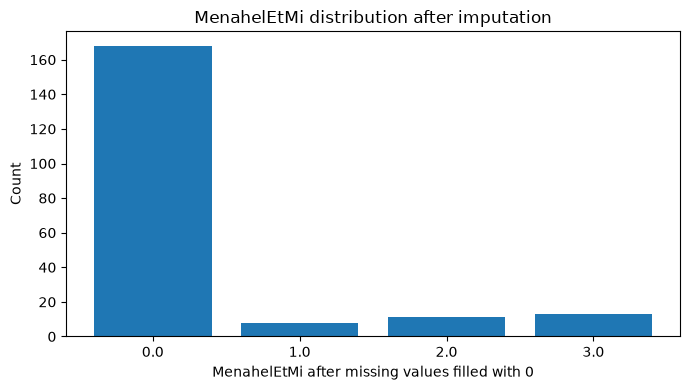

In [16]:
if "MenahelEtMi" in df.columns:
    menahel_after = df["MenahelEtMi"].fillna(0).astype(str).value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(menahel_after.index, menahel_after.values)
    ax.set_xlabel("MenahelEtMi after missing values filled with 0")
    ax.set_ylabel("Count")
    ax.set_title("MenahelEtMi distribution after imputation")
    plt.tight_layout()
    plt.show()


## 9. Text fields and text length

BOW and TF-IDF use plain combined text without a descriptive prefix. Sentence embeddings use the Hebrew descriptive prefix because it provides context to the sentence-transformer model.

Text fields used:
- EzoAvoda
- SugAvoda
- ShemAvoda
- ShemMachlaka
- SugMachlaka
- TeurPeula
- TeurTafkid


,count,mean,std,min,25%,50%,75%,max
text_char_count,200.0,52.915,30.318042,5.0,32.0,48.0,69.25,149.0
text_word_count,200.0,10.990,5.782481,1.0,7.0,10.0,14.25,30.0
text_non_missing_field_count,200.0,4.190,1.327672,1.0,3.0,4.0,5.00,7.0


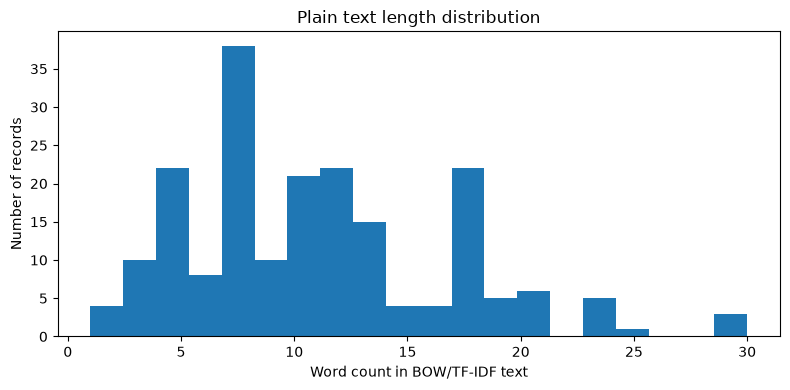

,ID,SemelMishlachSofi,bow_tfidf_text,embedding_text
0,1.0,2120,"סגן מנהל אגף | איסוף, עיבוד ופרסום נתונים | למ""ס | מיקרו כלכלה | טיפול בנתוני מיקרו","תיאור מקום עבודה ותפקיד: סגן מנהל אגף ,איסוף, עיבוד ופרסום נתונים ,למ""ס ,מיקרו כלכלה ,טיפול בנתו..."
1,2.0,3311,טכנאית רדיותרפיה | טיפול בחולים | בית חולים הדסה עין כרם | רדיואתרפיה | טיפול בחולי סרטן,"תיאור מקום עבודה ותפקיד: טכנאית רדיותרפיה ,טיפול בחולים ,בית חולים הדסה עין כרם ,רדיואתרפיה ,טיפ..."
2,3.0,3512,נותנת תמיכה ללקוחות שמבקשים עזרה | מתן שירות למשתמשים באתר GOV | קריית הממשלה | תמיכה בלקוחות | ...,"תיאור מקום עבודה ותפקיד: נותנת תמיכה ללקוחות שמבקשים עזרה ,מתן שירות למשתמשים באתר GOV ,קריית המ..."
3,4.0,5414,שומר בבית הספר | בית ספר יסודי | משרד החינוך | שמירה,"תיאור מקום עבודה ותפקיד: שומר בבית הספר ,בית ספר יסודי ,משרד החינוך ,שמירה"
4,5.0,5322,"מטפל בקשיש | מטפל בקשיש במשפחה | אמיר כהן | נותן אוכל, עוזר בניקיון בית, עוזר להתרחץ","תיאור מקום עבודה ותפקיד: מטפל בקשיש ,מטפל בקשיש במשפחה ,אמיר כהן ,נותן אוכל, עוזר בניקיון בית, ע..."


In [17]:
print("Text fields used:")
for col in TEXT_ORDER_FOR_BASELINE:
    if col in df.columns:
        print("-", col)

text_summary = df[["text_char_count", "text_word_count", "text_non_missing_field_count"]].describe().T
display(text_summary)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["text_word_count"], bins=20)
ax.set_xlabel("Word count in BOW/TF-IDF text")
ax.set_ylabel("Number of records")
ax.set_title("Plain text length distribution")
plt.tight_layout()
plt.show()

display(
    df[
        [ID_COL, TARGET_COL, "bow_tfidf_text", "embedding_text"]
    ].head(5)
)


## 10. Binary BOW document-frequency analysis

Each token is counted once per record. The sentence-transformer prefix is not included in this BOW analysis.

BOW vocabulary size: 428


,metric,value
0,Number of records,200
1,Vocabulary size,428
2,Non-zero document-token entries,"1,482"
3,Matrix density,1.73%
4,Matrix sparsity,98.27%
5,Average active tokens per record,7
6,Median active tokens per record,7
7,Min active tokens per record,1
8,Max active tokens per record,20


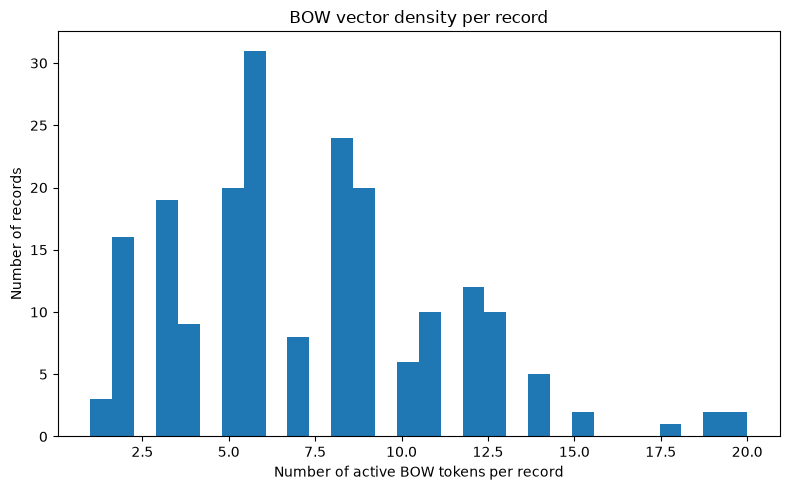

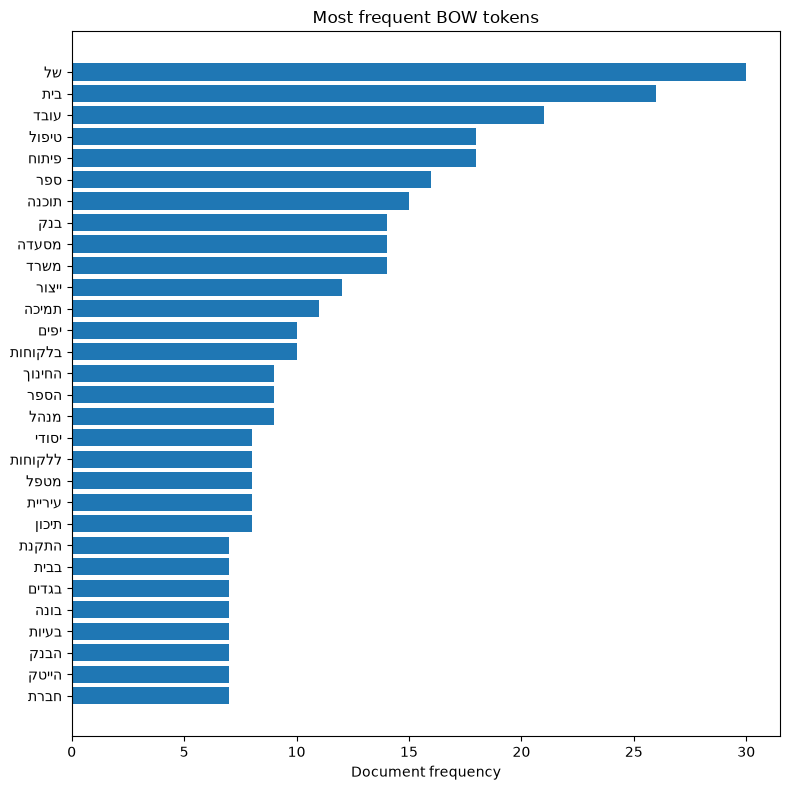

Rare tokens: number of tokens appearing in exactly one record: 132


,group,token,document_frequency,document_fraction
0,most frequent,של,30,15.0%
1,most frequent,בית,26,13.0%
2,most frequent,עובד,21,10.5%
3,most frequent,טיפול,18,9.0%
4,most frequent,פיתוח,18,9.0%
5,most frequent,ספר,16,8.0%
6,most frequent,תוכנה,15,7.5%
7,most frequent,בנק,14,7.0%
8,most frequent,מסעדה,14,7.0%
9,most frequent,משרד,14,7.0%


In [18]:
bow_freq, bow_matrix, bow_vectorizer = bow_document_frequency(
    df,
    text_col="bow_tfidf_text",
    max_features=BOW_MAX_FEATURES,
)

print(f"BOW vocabulary size: {len(bow_freq):,}")

import numpy as np
import pandas as pd

# Vector density diagnostics
# For a sparse BOW matrix, density = share of non-zero cells out of all possible document-token cells.
bow_matrix = bow_matrix.tocsr()

n_records, n_features = bow_matrix.shape
n_nonzero = bow_matrix.nnz

bow_density = n_nonzero / (n_records * n_features)
bow_sparsity = 1 - bow_density

nonzero_per_record = np.diff(bow_matrix.indptr)

density_summary = pd.DataFrame(
    {
        "metric": [
            "Number of records",
            "Vocabulary size",
            "Non-zero document-token entries",
            "Matrix density",
            "Matrix sparsity",
            "Average active tokens per record",
            "Median active tokens per record",
            "Min active tokens per record",
            "Max active tokens per record",
        ],
        "value": [
            n_records,
            n_features,
            n_nonzero,
            bow_density,
            bow_sparsity,
            nonzero_per_record.mean(),
            np.median(nonzero_per_record),
            nonzero_per_record.min(),
            nonzero_per_record.max(),
        ],
    }
)

display(
    density_summary.style.format(
        {
            "value": lambda x: f"{x:,.0f}" if abs(x) >= 1 else f"{x:.2%}"
        }
    )
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(nonzero_per_record, bins=30)
ax.set_xlabel("Number of active BOW tokens per record")
ax.set_ylabel("Number of records")
ax.set_title("BOW vector density per record")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
plot_df = bow_freq.head(30).sort_values("document_frequency")
ax.barh(plot_df["token"], plot_df["document_frequency"])
ax.set_xlabel("Document frequency")
ax.set_title("Most frequent BOW tokens")
plt.tight_layout()
plt.show()

print("Rare tokens: number of tokens appearing in exactly one record:", int((bow_freq["document_frequency"] == 1).sum()))

display(
    pd.concat(
        [
            bow_freq.head(20).assign(group="most frequent"),
            bow_freq.sort_values(["document_frequency", "token"]).head(20).assign(group="least frequent"),
        ],
        ignore_index=True,
    )[["group", "token", "document_frequency", "document_fraction"]].style.format({"document_fraction": "{:.1%}"})
)

## 11. Exploratory vector separability

BOW and TF-IDF are computed from text only. Silhouette and centroid diagnostics test whether records are closer to their own code group than to other groups. These are exploratory summaries, not validation metrics.

,vector_representation,label,n_samples_used,n_labels_used,min_group_size,silhouette_score
0,BOW,target_l1,196,8,2,0.073
1,BOW,target_l2,189,26,2,0.245
2,BOW,target_l3,179,33,2,0.417
3,BOW,target_l4,167,35,2,0.539
4,TF-IDF,target_l1,196,8,2,0.080
5,TF-IDF,target_l2,189,26,2,0.265
6,TF-IDF,target_l3,179,33,2,0.436
7,TF-IDF,target_l4,167,35,2,0.564


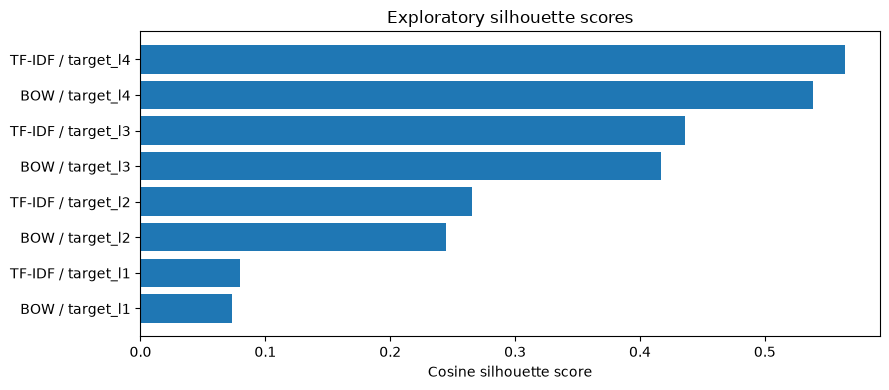

In [19]:
bow_X, _ = vectorize_text(
    df,
    text_col="bow_tfidf_text",
    vectorizer_type="bow",
    max_features=BOW_MAX_FEATURES,
)

tfidf_X, _ = vectorize_text(
    df,
    text_col="bow_tfidf_text",
    vectorizer_type="tfidf",
    max_features=TFIDF_MAX_FEATURES,
)

silhouette_rows = []

for vector_name, X in [("BOW", bow_X), ("TF-IDF", tfidf_X)]:
    for label_col in ["target_l1", "target_l2", "target_l3", "target_l4"]:
        result = compute_silhouette_for_labels(
            X,
            df[label_col],
            metric="cosine",
            min_group_size=2,
        )
        result["vector_representation"] = vector_name
        result["label"] = label_col
        silhouette_rows.append(result)

silhouette_df = pd.DataFrame(silhouette_rows)[
    [
        "vector_representation",
        "label",
        "n_samples_used",
        "n_labels_used",
        "min_group_size",
        "silhouette_score",
    ]
]

display(silhouette_df.style.format({"silhouette_score": "{:.3f}"}))

plot_df = silhouette_df.dropna(subset=["silhouette_score"]).copy()
plot_df["x_label"] = plot_df["vector_representation"] + " / " + plot_df["label"]
plot_df = plot_df.sort_values("silhouette_score")

fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(plot_df))))
ax.barh(plot_df["x_label"], plot_df["silhouette_score"])
ax.set_xlabel("Cosine silhouette score")
ax.set_title("Exploratory silhouette scores")
plt.tight_layout()
plt.show()


## 12. sentence-embedding diagnostics

This section runs only if `survey_with_embeddings.pkl` exists. It compares embedding separability with BOW and TF-IDF and displays a simple PCA projection by broad occupation group.

In [20]:
embeddings_df = load_embeddings_if_available(
    EMBEDDINGS_PATH,
    id_col=ID_COL,
    embedding_col=EMBEDDING_COL,
)

if embeddings_df is None:
    print("Embedding file was not found. Skipping embedding-vector diagnostics.")
    embeddings_available = False
else:
    embeddings_available = True

    df_with_embeddings = df.merge(
        embeddings_df,
        on=ID_COL,
        how="left",
        validate="one_to_one",
    )

    missing_embeddings = df_with_embeddings[EMBEDDING_COL].isna().sum()
    valid_embedding_mask, embedding_matrix = stack_embedding_column(
        df_with_embeddings,
        embedding_col=EMBEDDING_COL,
    )

    embedding_overview = pd.DataFrame(
        {
            "metric": [
                "embedding rows",
                "records missing embedding after ID merge",
                "embedding matrix rows",
                "embedding dimensions",
            ],
            "value": [
                len(embeddings_df),
                int(missing_embeddings),
                embedding_matrix.shape[0],
                embedding_matrix.shape[1] if embedding_matrix.size else 0,
            ],
        }
    )
    display(embedding_overview)


,metric,value
0,embedding rows,200
1,records missing embedding after ID merge,0
2,embedding matrix rows,200
3,embedding dimensions,768


,vector_representation,label,n_samples_used,n_labels_used,min_group_size,silhouette_score
0,BOW,target_l1,196,8,2,0.073
1,BOW,target_l2,189,26,2,0.245
2,BOW,target_l3,179,33,2,0.417
3,BOW,target_l4,167,35,2,0.539
4,TF-IDF,target_l1,196,8,2,0.080
5,TF-IDF,target_l2,189,26,2,0.265
6,TF-IDF,target_l3,179,33,2,0.436
7,TF-IDF,target_l4,167,35,2,0.564
8,Embeddings,target_l1,196,8,2,0.037
9,Embeddings,target_l2,189,26,2,0.184


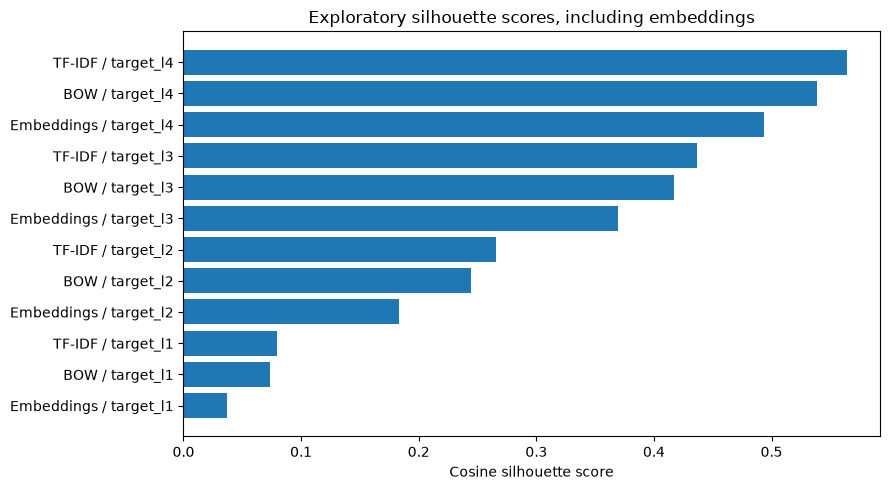

In [21]:
target_level_cols = ["target_l1", "target_l2", "target_l3", "target_l4"]


if embeddings_available:
    embedding_silhouette_rows = []

    for label_col in target_level_cols:
        labels = df_with_embeddings.loc[valid_embedding_mask, label_col]
        result = compute_silhouette_for_labels(
            embedding_matrix,
            labels,
            metric="cosine",
            min_group_size=2,
        )
        result["vector_representation"] = "Embeddings"
        result["label"] = label_col
        embedding_silhouette_rows.append(result)

    embedding_silhouette_df = pd.DataFrame(embedding_silhouette_rows)[
        [
            "vector_representation",
            "label",
            "n_samples_used",
            "n_labels_used",
            "min_group_size",
            "silhouette_score",
        ]
    ]

    all_silhouette_df = pd.concat([silhouette_df, embedding_silhouette_df], ignore_index=True)

    display(all_silhouette_df.style.format({"silhouette_score": "{:.3f}"}))

    plot_df = all_silhouette_df.dropna(subset=["silhouette_score"]).copy()
    plot_df["x_label"] = plot_df["vector_representation"] + " / " + plot_df["label"]
    plot_df = plot_df.sort_values("silhouette_score")

    fig, ax = plt.subplots(figsize=(9, max(5, 0.35 * len(plot_df))))
    ax.barh(plot_df["x_label"], plot_df["silhouette_score"])
    ax.set_xlabel("Cosine silhouette score")
    ax.set_title("Exploratory silhouette scores, including embeddings")
    plt.tight_layout()
    plt.show()


## 13. Population representation

Since the data set is small, I can assume that many occupations are unrepresented 
in the given data set. \
The following are just small chckes to get a general overview. \
In the modeling part, I performed random k-fold cross validation so each fold contains new categories in the validation set. \
In real life, we might consider setting rules for manual tagging for unrepresented groups (in case we don't want to systematically fail with rare categories).

In [22]:
df.MaamadAvoda.value_counts().sort_index() # There are unrepresented groups 

 

MaamadAvoda
1    177
2      1
4     10
6     10
Name: count, dtype: int64

In [23]:
df.TeudaGvoha.value_counts().sort_index()

TeudaGvoha
1     3
2    12
3    57
4    58
5    25
6    39
7     4
Name: count, dtype: int64

In [24]:

DUPLICATE_KEY_COLUMNS = [
    "ShemAvoda",
    "SugAvoda",
    "ShemMachlaka",
    "SugMachlaka",
    "EzoAvoda",
    "TeurPeula",
    "TeurTafkid",
    "MenahelEtMi",
    "MakorSachar",
    "MaamadAvoda",
    "TeudaGvoha",
    "shnotlimud",
    "Gil",
    "TarichHathala",
    "SemelAnafSofi'"
    
]

# Keep only columns that actually exist in the dataset
DUPLICATE_KEY_COLUMNS = [c for c in DUPLICATE_KEY_COLUMNS if c in df.columns]

analysis_df = df.copy()

# Normalize text/key fields so that small formatting differences do not hide duplicates
for col in DUPLICATE_KEY_COLUMNS:
    analysis_df[col] = (
        analysis_df[col]
        .astype("string")
        .fillna("<missing>")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )



# Count how many rows and how many distinct targets exist per duplicate-key group
duplicate_target_summary = (
    analysis_df
    .groupby(DUPLICATE_KEY_COLUMNS, dropna=False)
    .agg(
        n_records=(ID_COL, "count"),
        n_unique_targets=(TARGET_COL, "nunique"),
        target_values=(TARGET_COL, lambda x: sorted(x.dropna().unique())),
        ids=(ID_COL, lambda x: list(x)),
    )
    .reset_index()
)

# Groups where the same input appears more than once with different target values
conflicting_duplicates = duplicate_target_summary[
    (duplicate_target_summary["n_records"] > 1)
    & (duplicate_target_summary["n_unique_targets"] > 1)
].sort_values(["n_unique_targets", "n_records"], ascending=False)

print("Duplicate-like input groups with different target values:", len(conflicting_duplicates))

display(
    conflicting_duplicates[
        ["n_records", "n_unique_targets", "target_values", "ids"] + DUPLICATE_KEY_COLUMNS
    ].head(20)
)

# Optional: show the original rows for the conflicting groups
if len(conflicting_duplicates) > 0:
    conflicting_keys = conflicting_duplicates[DUPLICATE_KEY_COLUMNS].drop_duplicates()

    conflicting_rows = analysis_df.merge(
        conflicting_keys,
        on=DUPLICATE_KEY_COLUMNS,
        how="inner",
    ).sort_values(DUPLICATE_KEY_COLUMNS + [TARGET_COL])

    display_cols = [ID_COL, TARGET_COL] + DUPLICATE_KEY_COLUMNS

    display_cols = [c for c in display_cols if c in conflicting_rows.columns]

    display(conflicting_rows[display_cols].head(50))

Duplicate-like input groups with different target values: 1


,n_records,n_unique_targets,target_values,ids,ShemAvoda,SugAvoda,ShemMachlaka,SugMachlaka,EzoAvoda,TeurPeula,TeurTafkid,MenahelEtMi,MakorSachar,MaamadAvoda,TeudaGvoha,shnotlimud,Gil,TarichHathala
30,4,2,"[3211, 3311]","[2.0, 33.0, 65.0, 96.0]",בית חולים הדסה עין כרם,טיפול בחולים,רדיואתרפיה,טיפול בחולי סרטן,טכנאית רדיותרפיה,"כנ""ל","כנ""ל",<missing>,1.0,1,6,22.0,55.0,2022-07-01


,ID,SemelMishlachSofi,ShemAvoda,SugAvoda,ShemMachlaka,SugMachlaka,EzoAvoda,TeurPeula,TeurTafkid,MenahelEtMi,MakorSachar,MaamadAvoda,TeudaGvoha,shnotlimud,Gil,TarichHathala
1,33.0,3211,בית חולים הדסה עין כרם,טיפול בחולים,רדיואתרפיה,טיפול בחולי סרטן,טכנאית רדיותרפיה,"כנ""ל","כנ""ל",<missing>,1.0,1,6,22.0,55.0,2022-07-01
2,65.0,3211,בית חולים הדסה עין כרם,טיפול בחולים,רדיואתרפיה,טיפול בחולי סרטן,טכנאית רדיותרפיה,"כנ""ל","כנ""ל",<missing>,1.0,1,6,22.0,55.0,2022-07-01
3,96.0,3211,בית חולים הדסה עין כרם,טיפול בחולים,רדיואתרפיה,טיפול בחולי סרטן,טכנאית רדיותרפיה,"כנ""ל","כנ""ל",<missing>,1.0,1,6,22.0,55.0,2022-07-01
0,2.0,3311,בית חולים הדסה עין כרם,טיפול בחולים,רדיואתרפיה,טיפול בחולי סרטן,טכנאית רדיותרפיה,"כנ""ל","כנ""ל",<missing>,1.0,1,6,22.0,55.0,2022-07-01


## 14. Summary for modeling

The EDA supports the modeling design:

1. The exact target, `SemelMishlachSofi`, contains many sparse categories. Therefore, exact 4-digit occupation-code prediction should be treated conservatively, especially for rare classes.

2. Codes containing `X` represent partial labels. These cases should not be evaluated as ordinary exact-label errors only, but with partial-code logic that gives credit for correctly predicting the known part of the hierarchy.

3. `SemelAnafSofi` appears to be strongly related to `SemelMishlachSofi`, and could potentially help narrow the occupation-code search space. However, I assume that `SemelAnafSofi` is not available at prediction time. Therefore, I decided not to use the true value directly and did not implement a two-stage prediction pipeline in the current solution. As a future improvement, a first-stage model could be trained to predict `SemelAnafSofi`, and its out-of-fold predictions could then be used as an additional leakage-safe feature for the final occupation-code model.

4. Many samples contain missing values in the workplace and role-description fields, and relevant information may appear across different text columns. Therefore, I combined the available text fields into a single textual representation, so that the model can use information from all available occupation-related descriptions rather than relying on one specific column.

5. The binary BOW representation provides a simple and interpretable text baseline. Although the BOW matrix is sparse in absolute terms, with 98.27% zero entries, each record activates about 7 vocabulary tokens on average out of a vocabulary of 428. Given the short job-description fields, this suggests that the BOW representation still captures useful textual signal. In addition, the vector-space diagnostics suggest that the text features form meaningful occupation-related clusters.\
However, at least some of the occupation-related fields appear to contain free-text responses, meaning that different respondents may use different words or phrases to describe similar occupations or tasks. In such cases, BOW and TF-IDF representations treat different words as unrelated features, even when they convey similar meanings. Sentence-transformer embeddings may better capture semantic similarity between responses that use different wording to express the same underlying occupation.\
At the same time, the text appears to exhibit relatively limited variation, possibly because the dataset is synthetic or because some fields contain structured or multiple-choice-like values. If the limited variation is not solely due to predefined response options, semantic embeddings may still provide additional value by grouping together semantically similar descriptions that do not share the same vocabulary. Therefore, I compare binary BOW, TF-IDF, and sentence-transformer embeddings in the modeling stage.

6. One duplicate-like input group was found where what is likely the same person appears multiple times but is associated with two different occupation codes (3211 and 3311). Given that the occupation-coding process is reported to have approximately 90% tagging accuracy, this discrepancy is not unexpected and may reflect labeling noise or ambiguity in the coding process.\
The duplicate analysis identified only a single conflicting duplicate-like group. I did not perform a broader near-duplicate search, so additional similar records may exist. If highly similar records appear in both training and validation folds, validation performance could be slightly optimistic. However, given the limited evidence of duplicates in the dataset, the impact is likely small.